In [1]:
using Pkg
Pkg.activate("../Project.toml")
Pkg.instantiate()

  Activating project at `~/Documents/GitHub/info-flow-dual-repo`


In [2]:
using CSV
using DataFrames
using Colors
using Plots
using Statistics
using StatsBase
using QuadGK
using Dates
using LaTeXStrings
using JLD2
using Distributions
using Random

include("../src/Estimation.jl")
include("../src/Analysis.jl")
include("../src/Plotting.jl")
Red = colorant"#FF644E"
Blue = colorant"#00A2FF"
gray = colorant"#5E5E5E"
binary(x) = x ? +1 : -1
binary_rand(n) = binary.(rand(n) .> 0.5)
default(
    tickfontsize=10,
    legendfontsize=10,
    guidefontsize=12,
    fontfamily="serif-roman"
)

### Fig. 2

In [3]:
β = 0.22
N = 6
R = 1.0
v = 20/10^3 #μm to mm

I_MK(c) = β * c^2
λ_GM(c) =  2*c * N*v/R;
λ_FS(c,σ) = 4*c^2 * v^2/(R*σ);
I_GM(c) = I(λ_GM(c))/log(2)
I_FS(c,σ) = I.(λ_FS.(c,σ))/log(2)

f1(Z) = Z*log(Z) + (1-Z) * log(1-Z)
f2(Z) = 1/(Z*(1-Z))
f_nomi(Z,λ) = f1(Z) * f2(Z)^2 * exp(-f2(Z)/λ)
f_deno(Z,λ) = f2(Z)^2 * exp(-f2(Z)/λ)
I(λ) = log(2) + quadgk(Z->f_nomi(Z,λ), 0.,1)[1]/quadgk(Z->f_deno(Z,λ),0.,1)[1]

using LsqFit,QuadGK
c_fit = [0.1,0.2,0.3,0.4];σ0 = 0.0001
σ_fit = curve_fit(I_FS, c_fit, I_MK.(c_fit)/(2R), [σ0]).param[1]
println("σ_fit = ", σ_fit)

σ_fit = 0.0012713732561689577


In [5]:
MI

Dict{String, Any} with 2 entries:
  "MI_LB" => [0.329485 0.0551393; 0.312122 0.100105; … ; 0.406036 0.145456; 0.4…
  "MI_UB" => [0.877457 0.10847; 0.814686 0.17756; … ; 0.907237 0.292628; 0.8679…

c = 0.4 I_FS(c,σ_fit) = 0.017512251208172337
c = 2.0 I_FS(c,σ_fit) = 0.2631319130796565


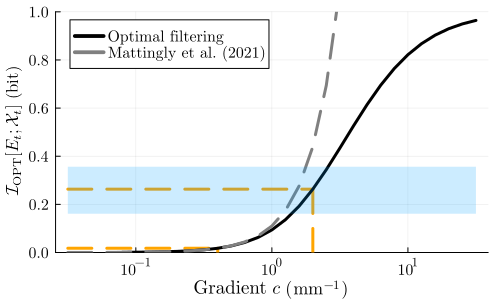

In [6]:
c = [10^x for x in -1.5:0.1:1.5]
MI = load("../data/MIest_main.jld2") #Data is generated in cells of Fig.1 in Fig1.ipynb
MI_up = MI["MI_UB"]; MI_lw = MI["MI_LB"]
MI_m = mean(MI_lw,dims=1)[1,1,:]
MI_m_max,MI_m_min = maximum(MI_m),minimum(MI_m)
plot()
for cc in [0.4,2.0]
    plot!(cc*ones(2),[0,I_FS.(cc,σ_fit)],linestyle=:dash,label="",color=:orange,linewidth=3)
    plot!([c[1],cc],I_FS.(cc,σ_fit)*ones(2),linestyle=:dash,label="",color=:orange,linewidth=3)
    #annotate!(cc,-0.05,("▲",:orange,8))
    println("c = ", cc, " I_FS(c,σ_fit) = ", I_FS(cc,σ_fit))
end
plot!(c,I_FS.(c,σ_fit),label="Optimal filtering",color=:black,linewidth=3)
plot!(c,I_MK.(c)/(2R),label="Mattingly et al. (2021)",color=:gray,linestyle=:dash,linewidth=3)

plot!(c,MI_m_max * ones(length(c)),fillrange=MI_m_min * ones(length(c)),fillalpha=0.2,fillcolor=Blue,linealpha=0,label="")
plot!(
    xscale = :log10,
    ylim = (0,1),
    legend=:topleft,
    xlabel = "Gradient \$c\$ \$(\\mathrm{mm}^{-1})\$",
    ylabel = "\$\\mathcal{I}_{\\mathrm{OPT}}[E_{t};\\mathcal{X}_{t}]\\ (\\mathrm{bit})\$",
    size = (500,300),
    yguidefontfamily="Bookman"
)
savefig("../figure/Iest_c.pdf")
plot!()

### Fig. S2

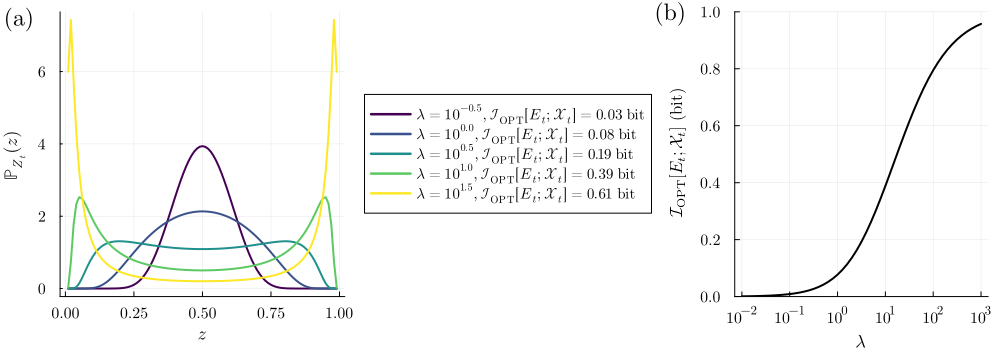

In [5]:
default(; # Plots defaults
    fontfamily="Computer modern",
    label="" # only explicit legend entries
    )
Prob(Z,λ) = f_deno(Z,λ)/quadgk(z->f_deno(z,λ),0,1)[1]
Z = 0.01:0.01:1-0.01
λlist = [10^x for x in -0.5:0.5:1.5]
plot()
palette_viridis = cgrad(:viridis,length(λlist), categorical=true)[1:length(λlist)]
for i_λ in 1:length(λlist)
    plot!(Z,[Prob.(z,λlist[i_λ]) for z in Z],label = "\$\\lambda=10^{$(log10(λlist[i_λ]))}, \\mathcal{I}_{\\mathrm{OPT}}[E_{t};\\mathcal{X}_{t}]=$(round(I(λlist[i_λ])/log(2),digits=2)) \\ \\mathrm{bit}\$",color=palette_viridis[i_λ],xlabel="\$z\$",ylabel="\$\\mathbb{P}_{Z_{t}}(z)\$",fontfamily="serif-roman",linewidth=2,legend=:outerright)
end
annotate!(-0.17,7.5,("(a)",:black,15))
p1 = plot!(size=(800,400))


λlist = [10^x for x in -2:0.1:3]
MI = load("../data/MIest_main.jld2")
MI_up = MI["MI_up"]; MI_lw = MI["MI_lw"]
MI_m = mean(MI_lw,dims=1)[1,1,:]
MI_m_max,MI_m_min = maximum(MI_m),minimum(MI_m)
plot()
plot!(λlist, [I(λ) for λ in λlist]/log(2),xticks=[10^x for x in -2.:3],xscale=:log10,xlabel="\$\\lambda\$",ylabel="\$\\mathcal{I}_{\\mathrm{OPT}}[E_{t};\\mathcal{X}_{t}]\\ (\\mathrm{bit})\$",linewidth=2,ylim=(0,1),color=:black,yguidefontfamily="Bookman")

annotate!(10^-3.5,1.0,("(b)",:black,15))
p2 = plot!()
plot(p1,p2,layout = grid(1,2,widths = [0.7,0.3]),size=(1000,350),left_margin=5Plots.mm,bottom_margin=5Plots.mm)
savefig("../figure/lambda_dependence.pdf")
plot!()

### Fig. S3

σ_fit=0.0012713732561689577
λ([0.4,2.0]) =[0.20135707492495752, 5.033926873123938]

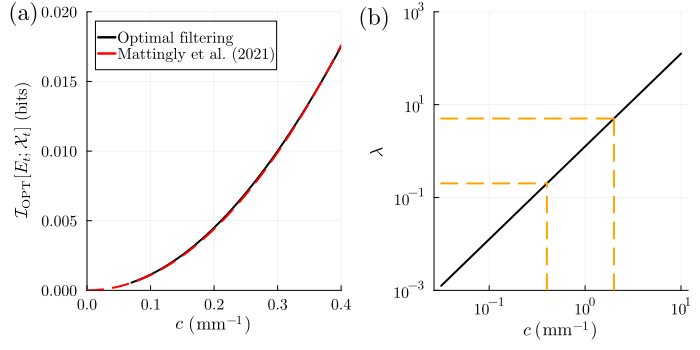

In [11]:
c = 0:0.01:0.5

plot(c,I_FS.(c,σ_fit),label="Optimal filtering",color=:black,linewidth=2)
plot!(c,I_MK.(c)/(2R),label="Mattingly et al. (2021)",color=:red,linestyle=:dash,linewidth=2)
annotate!(-0.1,0.02,("(a)",:black,15))
p1 = plot!(
    xlim = (0,0.4),
    ylim = (0,0.02),
    legend = :topleft,
    xlabel = "\$c\$ \$(\\mathrm{mm}^{-1})\$",
    ylabel = "\$\\mathcal{I}_{\\mathrm{OPT}}[E_{t};\\mathcal{X}_{t}]\\ (\\mathrm{bits})\$",
    yguidefontfamily = "Bookman"
)
println("σ_fit=", σ_fit)

unit = 10^3
clist = [10^x for x in -4.5:0.1:-2] * unit
λlist = [10^x for x in -2:0.1:3]

p_λmin,p_λmax = 10^(-3.),10^(3.)
plot(clist,λ_FS.(clist,σ_fit),xscale=:log10,yscale=:log10,linewidth=2,xlabel="\$c\\ (\\mathrm{mm}^{-1})\$",ylim=(p_λmin,p_λmax),ylabel="\$\\lambda\$",color=:black,y_ticks = [10^x for x in log10(p_λmin):2:log10(p_λmax)])

cmin,cmax = [10^-4,2*10^-3]*unit
λmin,λmax = λ_FS.([cmin,cmax],σ_fit)
for cc in [0.4,2.0]
    plot!(cc*ones(2),[p_λmin,λ_FS.(cc,σ_fit)],linestyle=:dash,color=:orange,linewidth=2)
    plot!([clist[1],cc],λ_FS.(cc,σ_fit)*ones(2),linestyle=:dash,label="",color=:orange,linewidth=2)
end
print("λ([0.4,2.0]) =", λ_FS.([0.4,2.0],σ_fit))
annotate!(10^-2.2,10^2.9,("(b)",:black,15))
p2 = plot!(legend=false)

plot(p1,p2,layout = grid(1,2,widths = [0.5,0.5]),size=(700,350),left_margin=5Plots.mm,bottom_margin=5Plots.mm)
savefig("../figure/sigma_fitting.pdf")
plot!()